# Progressão Geométrica

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** noção de sequência, termo geral e lei de formação explícita/recursiva, vista em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb); a progressão aritmética, vista em [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb), que serve de contraste direto para a PG (razão que soma × razão que multiplica); e a função exponencial, vista em [`0202a_funcao_exponencial.ipynb`](../02_logaritmos/0202a_funcao_exponencial.ipynb)

**Objetivos de aprendizagem:**
- Reconhecer uma PG e classificá-la quanto à razão (crescente, decrescente, constante ou oscilante).
- Encontrar o termo geral de uma PG e usá-lo para interpolar meios geométricos entre dois números.
- Calcular o produto e a soma dos termos de uma PG finita.
- Compreender a ideia de limite de uma sequência e calcular a soma de uma PG infinita convergente.

**Tempo estimado:** 75 a 90 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0303a_progressao_geometrica.ipynb)

📖 **Leitura complementar:** [Progressão geométrica](https://pt.wikipedia.org/wiki/Progress%C3%A3o_geom%C3%A9trica)

## A lenda do tabuleiro de xadrez

Reza a lenda que o inventor do jogo de xadrez apresentou sua criação a um rei, que ficou tão impressionado que ofereceu qualquer recompensa que o inventor pedisse. O pedido pareceu modesto: grãos de trigo sobre o tabuleiro — 1 grão na primeira casa, 2 na segunda, 4 na terceira, e assim por diante, **dobrando** a cada uma das 64 casas.

O rei riu da simplicidade do pedido... até seus contadores começarem a fazer as contas.

**Antes de continuar, pense um pouco:** na PA do notebook anterior, cada passo *somava* sempre a mesma quantidade — um crescimento que, por mais rápido, ainda é "administrável". Aqui, cada passo *multiplica* por 2. Você acha que o total de grãos no tabuleiro inteiro vai caber numa colher, num caminhão, ou em algo bem maior? Guarde seu palpite — vamos calcular o total exato na seção de Soma, mais adiante.

🕵️ **Curiosidade histórica:** essa lenda tem várias versões (às vezes o inventor é chamado Sessa, e já apareceu no notebook [`0201a_potencias_e_raizes.ipynb`](../02_logaritmos/0201a_potencias_e_raizes.ipynb) para motivar potências). O total de grãos, como veremos, é 2⁶⁴ − 1 — um número tão grande que nem toda a produção mundial de trigo de vários séculos somada seria suficiente para pagá-lo.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def gerar_pg(a1: float, q: float, n: int) -> np.ndarray:
    """Gera os n primeiros termos de uma PG de primeiro termo a1 e razao q."""
    indices = np.arange(1, n + 1)
    return a1 * q ** (indices - 1)


## 1. O que é uma Progressão Geométrica

Olhe para a sequência (3, 6, 12, 24, 48, 96). Repare que a *razão* entre um termo e o anterior é sempre a mesma: 6/3 = 2, 12/6 = 2, 24/12 = 2. Uma sequência assim é uma **progressão geométrica** (PG).

Compare com a PA do notebook anterior: lá, a diferença entre termos consecutivos era constante (somava sempre r). Aqui, é o **quociente** entre termos consecutivos que é constante — a PG multiplica sempre pelo mesmo número.

📌 **Definição formal:** uma **progressão geométrica** é uma sequência (aₙ) em que o quociente entre cada termo (a partir do segundo) e o termo anterior é sempre a mesma constante **q**, chamada de **razão** da PG:

$$\frac{a_n}{a_{n-1}} = q \quad \text{para todo } n \geq 2 \qquad (a_n \neq 0)$$

Isso é o mesmo que dizer que a PG tem **lei de formação recursiva** aₙ = aₙ₋₁ · q, com a₁ dado — a mesma ideia de lei recursiva vista em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb), só que agora o passo é "multiplicar por q" em vez de "somar r".

📎 **Conexão:** PA soma sempre o mesmo (r); PG multiplica sempre o mesmo (q). É exatamente esse contraste — visto de frente em [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb) — que dá nome às duas progressões.

Vamos representar a PG (3, 6, 12, 24, 48, 96) de três formas: algébrica (a lei recursiva), numérica (tabela) e gráfica (pontos — repare como a escala do eixo y precisa crescer rápido).

,n,a_n,a_n / a_(n-1)
0,1,3,NaN
1,2,6,2.0
2,3,12,2.0
3,4,24,2.0
4,5,48,2.0
5,6,96,2.0


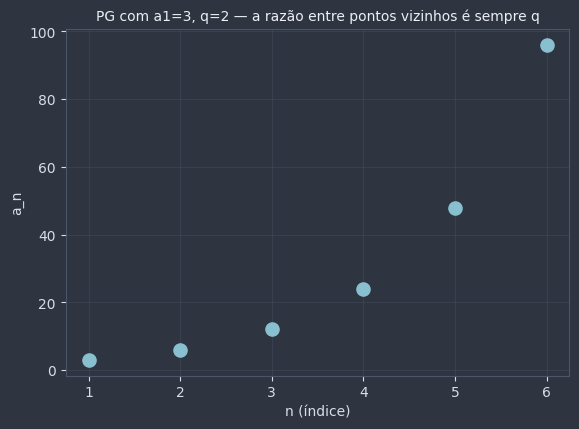

In [2]:
a1_exemplo = 3
q_exemplo = 2
n_exemplo = 6

termos_exemplo = gerar_pg(a1_exemplo, q_exemplo, n_exemplo)
indices_exemplo = np.arange(1, n_exemplo + 1)

razoes = termos_exemplo[1:] / termos_exemplo[:-1]
tabela_exemplo = pd.DataFrame({
    "n": indices_exemplo,
    "a_n": termos_exemplo,
    "a_n / a_(n-1)": [None] + list(razoes),
})
display(tabela_exemplo)

fig, ax = plt.subplots(figsize=(6.5, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.scatter(indices_exemplo, termos_exemplo, s=90, color=COR_PONTO, zorder=3)
ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
ax.set_xticks(indices_exemplo)
ax.set_title(
    f"PG com a1={a1_exemplo}, q={q_exemplo} — a razão entre pontos vizinhos é sempre q",
    color=NORD_TEXTO, fontsize=10,
)
plt.show()


**Pergunta de checagem:** na tabela acima, por que a primeira linha da coluna "a_n / a_(n−1)" fica vazia? E por que, diferente da PA, aqui usamos divisão em vez de subtração?

🎯 **Aplicação prática:** uma célula que se divide em duas a cada geração gera uma PG de razão 2 (número de células); uma folha de papel dobrada ao meio repetidamente tem sua espessura multiplicada por 2 a cada dobra — também uma PG.

## 2. Classificação quanto à razão

Na PA, a classificação dependia só do sinal de r. Na PG é um pouco mais sutil: depende do sinal de **q** *e* do sinal de **a₁** juntos.

- **Crescente**: os termos aumentam a cada passo — acontece quando (a₁ > 0 e q > 1) ou (a₁ < 0 e 0 < q < 1).
- **Decrescente**: os termos diminuem a cada passo — acontece quando (a₁ > 0 e 0 < q < 1) ou (a₁ < 0 e q > 1).
- **Constante**: q = 1 — todos os termos são iguais a a₁.
- **Oscilante (ou alternante)**: q < 0 — os termos alternam de sinal a cada passo. Esse comportamento **não existe** em PA.

(O caso q = 0 não define uma PG — a razão entre termos deixaria de existir a partir do segundo termo nulo.)

⚠️ **Erro comum 1:** achar que "razão maior que 1 sempre cresce". Falso — se a₁ for **negativo**, uma razão q > 1 torna a PG **decrescente** (os termos ficam cada vez mais negativos).

⚠️ **Erro comum 2:** achar que "razão entre 0 e 1 significa termos negativos". Falso — 0 < q < 1 só faz os termos **encolherem em direção a zero**, mantendo o sinal de a₁. Uma PG com a₁ > 0 e 0 < q < 1 tem todos os termos positivos, só que cada vez menores.

a1=   2, q=   2 -> classificação: crescente
a1=  64, q= 0.5 -> classificação: decrescente
a1=   5, q=   1 -> classificação: constante
a1=   3, q=  -2 -> classificação: oscilante


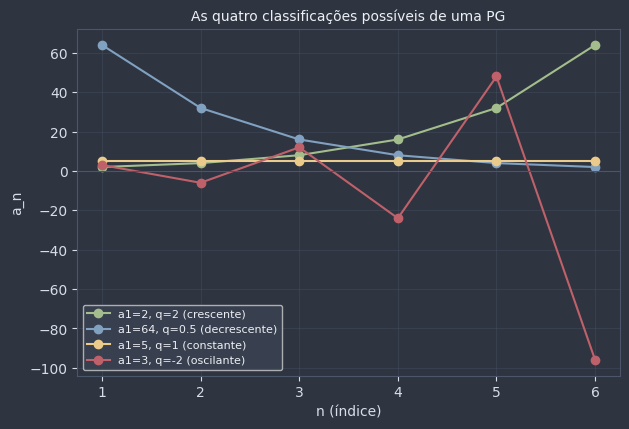


contraexemplo -> a1=-2, q=3: termos = [  -2   -6  -18  -54 -162], classificação: decrescente


In [3]:
def classificar_pg(a1: float, q: float) -> str:
    """Classifica uma PG em crescente, decrescente, constante ou oscilante."""
    if q == 0:
        raise ValueError("q = 0 não define uma progressão geométrica")
    if q < 0:
        return "oscilante"
    if q == 1:
        return "constante"
    if a1 > 0:
        return "crescente" if q > 1 else "decrescente"
    return "decrescente" if q > 1 else "crescente"


exemplos = [
    {"a1": 2, "q": 2, "n": 6},
    {"a1": 64, "q": 0.5, "n": 6},
    {"a1": 5, "q": 1, "n": 6},
    {"a1": 3, "q": -2, "n": 6},
]
cores_exemplos = [COR_DESTAQUE, COR_SECUNDARIA, COR_AVISO, COR_ALERTA]

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)

for exemplo, cor in zip(exemplos, cores_exemplos, strict=True):
    termos = gerar_pg(exemplo["a1"], exemplo["q"], exemplo["n"])
    indices = np.arange(1, exemplo["n"] + 1)
    classificacao = classificar_pg(exemplo["a1"], exemplo["q"])
    ax.plot(
        indices, termos, "o-", color=cor,
        label=f"a1={exemplo['a1']}, q={exemplo['q']} ({classificacao})",
    )
    print(f"a1={exemplo['a1']:>4}, q={exemplo['q']:>4} -> classificação: {classificacao}")

ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)
ax.set_title("As quatro classificações possíveis de uma PG", color=NORD_TEXTO, fontsize=10)
plt.show()

# Contraexemplo do erro comum 1: razão > 1, mas a1 negativo -> PG decrescente
a1_contra, q_contra, n_contra = -2, 3, 5
termos_contra = gerar_pg(a1_contra, q_contra, n_contra)
print(
    f"\ncontraexemplo -> a1={a1_contra}, q={q_contra}: termos = {termos_contra}, "
    f"classificação: {classificar_pg(a1_contra, q_contra)}"
)


**Pergunta de checagem:** no contraexemplo acima (a1 = −2, q = 3), os termos ficam cada vez "maiores em módulo" — então por que a PG é classificada como decrescente, e não crescente?

## 3. Notações especiais: PG de 3 e de 4 termos

Assim como na PA, quando um problema envolve **poucos termos** (3 ou 4) de uma PG e pede para descobrí-los a partir de soma e produto, existe uma notação centralizada que simplifica as contas — só que aqui centralizamos em torno de uma incógnita **x** usando *divisão e multiplicação* por q, em vez de subtração e adição.

📌 **PG de 3 termos**, centrada em x, com razão q:

$$\left(\frac{x}{q},\ x,\ x \cdot q\right)$$

📌 **PG de 4 termos**, centrada entre os dois termos do meio, com razão q:

$$\left(\frac{x}{q^3},\ \frac{x}{q},\ x \cdot q,\ x \cdot q^3\right)$$

A vantagem: multiplicando os 3 termos, os "q" se cancelam e sobra x³ — o que já revela x direto a partir do produto, sem resolver um sistema. (Compare com a PA: lá era a *soma* que cancelava os "±r"; aqui é o *produto* que cancela os "q" e "/q".)

Vamos usar essa ideia para resolver: **três números em PG têm soma 26 e produto 216. Quais são eles?**

In [4]:
soma_dada = 26
produto_dado = 216

# Com a notacao (x/q, x, x*q): produto = x^3, entao x = produto^(1/3)
x = produto_dado ** (1 / 3)
print(f"produto = x^3  ->  x = {x:g}")

# soma = x/q + x + x*q = x*(1/q + 1 + q) = soma_dada
# dividindo por x: 1/q + 1 + q = soma_dada / x
# multiplicando por q: q^2 + (1 - soma_dada/x)*q + 1 = 0
b = 1 - soma_dada / x
c = 1
raizes_q = np.roots([1, b, c])
q = float(raizes_q[raizes_q > 1][0])  # escolhendo a raiz que da uma PG crescente
print(f"resolvendo a equação do 2º grau em q, as raízes são: {raizes_q}")
print(f"escolhendo q = {q:g}")

numeros = (x / q, x, x * q)
print(f"os três números em PG: {tuple(round(n, 4) for n in numeros)}")
print(f"conferindo: soma = {sum(numeros):g}, produto = {numeros[0] * numeros[1] * numeros[2]:g}")


produto = x^3  ->  x = 6
resolvendo a equação do 2º grau em q, as raízes são: [3.         0.33333333]
escolhendo q = 3
os três números em PG: (2.0, 6.0, 18.0)
conferindo: soma = 26, produto = 216


📎 **Conexão:** assim como na PA, essa notação centralizada é só um truque algébrico — não um conceito novo — útil quando o número de termos é pequeno e conhecido de antemão.

**Pergunta de checagem:** por que, na notação de 3 termos, multiplicar os três termos (x/q, x, x·q) elimina a razão q e sobra x³?

## 4. Fórmula do termo geral

A lei recursiva aₙ = aₙ₋₁ · q é ótima para entender a PG, mas para chegar direto ao termo 20 ela obriga a calcular os 19 anteriores. Precisamos de uma **lei explícita**.

Pense assim: para ir de a₁ até aₙ, você dá **n − 1 passos**, cada um multiplicando por q:

$$a_1 \xrightarrow{\times q} a_2 \xrightarrow{\times q} a_3 \xrightarrow{\times q} \cdots \xrightarrow{\times q} a_n$$

Como são n − 1 multiplicações por q a partir de a₁:

📌 **Fórmula do termo geral:**

$$a_n = a_1 \cdot q^{\,n - 1}$$

🕹️ **Widget interativo:** ajuste a₁, q e n e veja o termo aₙ sendo calculado e destacado sobre o restante da PG. Marque a opção de escala logarítmica para "domar" o crescimento rápido no eixo y (só funciona bem quando todos os termos são positivos).

In [5]:
def explorar_termo_geral(a1: float, q: float, n: int, escala_log: bool) -> None:
    n_fundo = max(n + 3, 12)
    indices_fundo = np.arange(1, n_fundo + 1)
    termos_fundo = gerar_pg(a1, q, n_fundo)
    termo_n = a1 * q ** (n - 1)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.scatter(indices_fundo, termos_fundo, s=50, color=NORD_LINHA, zorder=2)
    ax.scatter([n], [termo_n], s=160, color=COR_ALERTA, zorder=4)
    if escala_log and a1 > 0 and q > 0:
        ax.set_yscale("log")
    ax.set_xlabel("n (índice)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("a_n", color=NORD_TEXTO_SEC)
    ax.set_title(f"a_{n} = {a1:g} · {q:g}^({n}-1) = {termo_n:g}", color=NORD_TEXTO, fontsize=11)
    plt.show()


widgets.interact(
    explorar_termo_geral,
    a1=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5, description="a1:"),
    q=widgets.FloatSlider(value=2.0, min=-3.0, max=3.0, step=0.5, description="q:"),
    n=widgets.IntSlider(value=5, min=1, max=12, step=1, description="n:"),
    escala_log=widgets.Checkbox(value=False, description="escala log (y)"),
)


interactive(children=(FloatSlider(value=1.0, description='a1:', max=5.0, min=0.5, step=0.5), FloatSlider(value…

<function __main__.explorar_termo_geral(a1: float, q: float, n: int, escala_log: bool) -> None>

📎 **Conexão:** essa fórmula é a versão explícita da mesma PG que definimos de forma recursiva no Bloco 1 — as duas leis (aₙ = aₙ₋₁·q e aₙ = a₁·qⁿ⁻¹) descrevem exatamente a mesma sequência, do mesmo jeito que vimos em [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb).

**Pergunta de checagem:** se a₁ e q são conhecidos, quantas multiplicações por q você precisa fazer para chegar em a₃₀? E em a₁?

## 5. Interpolação geométrica

**Interpolar k meios geométricos** entre dois números dados a₁ e aₙ significa encontrar k números que, junto com a₁ e aₙ, formam uma PG.

Se vamos inserir k meios entre a₁ e aₙ, a PG final tem n = k + 2 termos (os 2 extremos + os k meios). Usando a fórmula do termo geral com esse n:

$$a_n = a_1 \cdot q^{\,n-1} \quad \Longrightarrow \quad q = \sqrt[n-1]{\frac{a_n}{a_1}} = \sqrt[k+1]{\frac{a_n}{a_1}}$$

Ou seja: basta calcular q a partir dos dois extremos e do número de termos, e depois gerar a PG inteira.

⚠️ **Erro comum:** quando **n − 1 é par** (raiz de índice par) e a₁ e aₙ têm **sinais diferentes**, a razão real da equação acima não existe — não há como interpolar uma PG real entre eles. Sempre confira o sinal de aₙ/a₁ antes de tirar a raiz.

**Exemplo:** interpolar 3 meios geométricos entre 2 e 32.

In [6]:
def interpolar_meios_geometricos(a1: float, an: float, k: int) -> np.ndarray:
    """Interpola k meios geométricos entre a1 e an, retornando a PG completa (n = k + 2 termos)."""
    n = k + 2
    razao_extremos = an / a1
    if (n - 1) % 2 == 0 and razao_extremos < 0:
        raise ValueError(
            "não existe interpolação geométrica real: raiz de índice par de número negativo"
        )
    q = razao_extremos ** (1 / (n - 1))
    return gerar_pg(a1, q, n)


pg_interpolada = interpolar_meios_geometricos(a1=2, an=32, k=3)
print(f"PG completa (extremos + meios): {pg_interpolada}")
print(f"apenas os 3 meios geométricos: {pg_interpolada[1:-1]}")


PG completa (extremos + meios): [ 2.  4.  8. 16. 32.]
apenas os 3 meios geométricos: [ 4.  8. 16.]


**Pergunta de checagem:** se a₁ = 5 e aₙ = −5, é possível interpolar 1 meio geométrico real entre eles (k = 1, logo n = 3)? Por quê?

## 6. Produto dos termos de uma PG finita

Assim como a PA tem fórmula fechada para a soma, a PG tem fórmula fechada para o **produto** dos seus n termos:

📌 **Fórmula do produto:**

$$P_n = a_1 \cdot a_2 \cdots a_n = (a_1 \cdot a_n)^{\,n/2}$$

💡 **Dica:** repare no paralelo com a soma da PA — lá era "soma dos extremos vezes n sobre 2"; aqui é "produto dos extremos elevado a n sobre 2". A mesma ideia de emparelhar extremos (a₁ com aₙ, a₂ com aₙ₋₁, ...) está por trás das duas fórmulas — só que uma soma os pares, a outra multiplica.

Vamos verificar a fórmula numa PG concreta, multiplicando os termos diretamente e comparando com a fórmula.

In [7]:
pg_produto = gerar_pg(a1=2, q=3, n=5)
print(f"PG: {pg_produto}")

produto_direto = np.prod(pg_produto)
produto_formula = (pg_produto[0] * pg_produto[-1]) ** (len(pg_produto) / 2)

print(f"produto multiplicando termo a termo: {produto_direto:g}")
print(f"produto pela fórmula (a1*an)^(n/2): {produto_formula:g}")
print(f"batem? {math.isclose(produto_direto, produto_formula)}")


PG: [  2   6  18  54 162]
produto multiplicando termo a termo: 1.88957e+06
produto pela fórmula (a1*an)^(n/2): 1.88957e+06
batem? True


**Pergunta de checagem:** por que a fórmula do produto usa (a₁·aₙ) elevado a n/2, e não simplesmente (a₁·aₙ)·n, como seria de se esperar por analogia direta com a soma da PA?

## 7. Propriedade da PG: cada termo é uma média

Uma consequência direta da razão constante: **cada termo de uma PG (a partir do segundo e até o penúltimo) é a média geométrica entre o termo anterior e o posterior.**

$$a_n^2 = a_{n-1} \cdot a_{n+1} \quad \Longrightarrow \quad a_n = \sqrt{a_{n-1} \cdot a_{n+1}} \ \ (\text{para termos positivos})$$

💡 **Dica:** essa propriedade é um atalho valioso — muitas vezes resolve um exercício sem precisar montar a fórmula do termo geral (foi exatamente essa ideia que usamos, sem citar o nome, na notação de 3 termos do Bloco 3).

In [9]:
pg_propriedade = gerar_pg(a1=4, q=2, n=6)
print(f"PG: {pg_propriedade}")

# Verificando a propriedade para cada termo interno (do 2o ao penúltimo)
for i in range(1, len(pg_propriedade) - 1):
    media_geometrica_vizinhos = math.sqrt(pg_propriedade[i - 1] * pg_propriedade[i + 1])
    print(
        f"a_{i+1} = {pg_propriedade[i]:g} | média geométrica dos vizinhos = "
        f"{media_geometrica_vizinhos:g} | bate? "
        f"{math.isclose(pg_propriedade[i], media_geometrica_vizinhos)}"
    )


PG: [  4   8  16  32  64 128]
a_2 = 8 | média geométrica dos vizinhos = 8 | bate? True
a_3 = 16 | média geométrica dos vizinhos = 16 | bate? True
a_4 = 32 | média geométrica dos vizinhos = 32 | bate? True
a_5 = 64 | média geométrica dos vizinhos = 64 | bate? True


**Pergunta de checagem:** essa propriedade usa raiz quadrada do produto dos vizinhos — o que pode dar errado se a PG tiver razão negativa (oscilante) e você tentar aplicar a fórmula ingenuamente?

## 8. Soma dos termos de uma PG finita

Hora de voltar ao gancho: qual é o total de grãos de trigo no tabuleiro de xadrez inteiro?

Para deduzir a fórmula, um truque clássico: seja Sₙ = a₁ + a₁q + a₁q² + ... + a₁qⁿ⁻¹. Multiplicando os dois lados por q:

$$q \cdot S_n = a_1 q + a_1 q^2 + \cdots + a_1 q^n$$

Subtraindo a primeira equação da segunda, quase tudo cancela (sobra só o primeiro termo de um lado e o último do outro):

$$q \cdot S_n - S_n = a_1 q^n - a_1 \quad \Longrightarrow \quad S_n (q - 1) = a_1 (q^n - 1)$$

📌 **Fórmula da soma:**

$$S_n = \frac{a_1 (q^n - 1)}{q - 1} \qquad (q \neq 1)$$

Se q = 1, a PG é constante e a soma é simplesmente Sₙ = n · a₁.

🕹️ **Widget interativo:** mexa no slider de n e veja a soma acumulada Sₙ crescer, termo a termo, para uma PG de a₁ e q à sua escolha (escala logarítmica ajuda a visualizar o crescimento explosivo).

In [ ]:
def explorar_soma_pg(a1: float, q: float, n: int, escala_log: bool) -> None:
    termos = gerar_pg(a1, q, n)
    indices = np.arange(1, n + 1)
    soma_acumulada = np.cumsum(termos)
    soma_formula = a1 * n if math.isclose(q, 1.0) else a1 * (q**n - 1) / (q - 1)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.bar(indices, soma_acumulada, color=COR_PONTO)
    if escala_log:
        ax.set_yscale("log")
    ax.set_xlabel("n (quantidade de termos somados)", color=NORD_TEXTO_SEC)
    ax.set_ylabel("S_n (soma acumulada)", color=NORD_TEXTO_SEC)
    ax.set_xticks(indices)
    ax.set_title(
        f"S_{n} = {a1:g}·({q:g}^{n}-1)/({q:g}-1) = {soma_formula:g}",
        color=NORD_TEXTO, fontsize=9,
    )
    plt.show()

    print(f"soma pela fórmula: {soma_formula:g} | soma acumulando termo a termo: {soma_acumulada[-1]:g}")


widgets.interact(
    explorar_soma_pg,
    a1=widgets.FloatSlider(value=1.0, min=0.5, max=5.0, step=0.5, description="a1:"),
    q=widgets.FloatSlider(value=2.0, min=0.5, max=3.0, step=0.5, description="q:"),
    n=widgets.IntSlider(value=6, min=1, max=15, step=1, description="n:"),
    escala_log=widgets.Checkbox(value=True, description="escala log (y)"),
)


interactive(children=(FloatSlider(value=1.0, description='a1:', max=5.0, min=0.5, step=0.5), FloatSlider(value…

<function __main__.explorar_soma_pg(a1: float, q: float, n: int, escala_log: bool) -> None>

In [11]:
# Resolvendo o gancho: total de grãos no tabuleiro de xadrez (64 casas)
a1_tabuleiro, q_tabuleiro, n_tabuleiro = 1, 2, 64
total_graos = a1_tabuleiro * (q_tabuleiro**n_tabuleiro - 1) // (q_tabuleiro - 1)
print(f"total de grãos no tabuleiro: {total_graos}")
print(f"total de grãos (2^64 - 1), conferindo: {2**64 - 1}")

# Para dar uma ideia de escala: a produção mundial de trigo em um ano e da ordem de 700 bilhões de graos
producao_mundial_ano = 700_000_000_000
print(
    f"\nisso equivale a aproximadamente {total_graos / producao_mundial_ano:,.0f} "
    "anos inteiros de produção mundial de trigo"
)


total de grãos no tabuleiro: 18446744073709551615
total de grãos (2^64 - 1), conferindo: 18446744073709551615

isso equivale a aproximadamente 26,352,492 anos inteiros de produção mundial de trigo


🎯 **Aplicação prática — juros compostos com aportes fixos:** se você deposita um valor fixo PMT ao final de cada mês, a juros compostos de taxa mensal i, o valor futuro depois de n meses é a soma de uma PG: cada depósito rende juros por um número diferente de meses, e o total é

$$FV = PMT \cdot \frac{(1+i)^n - 1}{i}$$

que é exatamente a fórmula de Sₙ com a₁ = PMT e q = (1 + i) — só reorganizada.

In [12]:
pmt = 300  # depósito mensal fixo, em reais
taxa_mensal = 0.005  # 0.5% ao mes
n_meses = 24

valor_futuro = pmt * ((1 + taxa_mensal) ** n_meses - 1) / taxa_mensal
total_depositado = pmt * n_meses

print(f"depósito mensal: R$ {pmt}")
print(f"total depositado em {n_meses} meses: R$ {total_depositado:.2f}")
print(f"valor futuro (com juros compostos): R$ {valor_futuro:.2f}")
print(f"juros ganhos: R$ {valor_futuro - total_depositado:.2f}")


depósito mensal: R$ 300
total depositado em 24 meses: R$ 7200.00
valor futuro (com juros compostos): R$ 7629.59
juros ganhos: R$ 429.59


**Pergunta de checagem:** por que a fórmula da soma da PG (diferente da soma da PA) exige que você saiba o valor de q, e não só de a₁, aₙ e n?

## 9. PG como função exponencial

Compare as duas fórmulas:

$$a_n = a_1 \cdot q^{\,n-1} \qquad \Longleftrightarrow \qquad f(x) = a \cdot b^{\,x}$$

Reescrevendo aₙ = (a₁/q) · qⁿ, fica claro: a fórmula do termo geral **tem exatamente a forma de uma função exponencial**, vista em [`0202a_funcao_exponencial.ipynb`](../02_logaritmos/0202a_funcao_exponencial.ipynb), com q no papel da base e n no papel do expoente x. A diferença é o domínio: a função exponencial é definida para todo x real (uma curva contínua), enquanto a PG só é definida para n inteiro positivo (pontos isolados sobre essa curva).

📎 **Conexão:** essa é a mesma relação discreto × contínuo que vimos entre a PA e a função afim, em [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb) — só que agora entre a PG e a exponencial, em vez da reta.

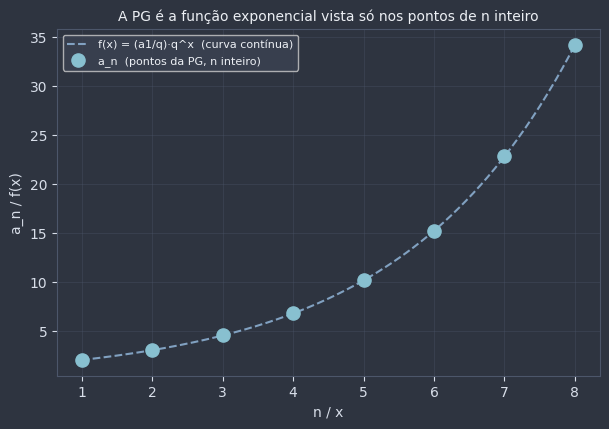

In [13]:
a1_exp, q_exp, n_exp = 2, 1.5, 8
indices_exp = np.arange(1, n_exp + 1)
termos_exp = gerar_pg(a1_exp, q_exp, n_exp)

x_continuo = np.linspace(1, n_exp, 200)
y_continuo = (a1_exp / q_exp) * q_exp**x_continuo

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
estilizar_eixo(ax)
ax.plot(
    x_continuo, y_continuo, "--", color=COR_SECUNDARIA, linewidth=1.5,
    label="f(x) = (a1/q)·q^x  (curva contínua)",
)
ax.scatter(
    indices_exp, termos_exp, s=90, color=COR_PONTO, zorder=3,
    label="a_n  (pontos da PG, n inteiro)",
)
ax.set_xlabel("n / x", color=NORD_TEXTO_SEC)
ax.set_ylabel("a_n / f(x)", color=NORD_TEXTO_SEC)
ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)
ax.set_title("A PG é a função exponencial vista só nos pontos de n inteiro", color=NORD_TEXTO, fontsize=10)
plt.show()


**Pergunta de checagem:** na reta contínua da PA (bloco anterior), a "inclinação" era constante (r). Na curva exponencial acima, a inclinação (taxa de variação) muda a cada ponto — o que isso revela sobre a diferença entre crescimento linear e crescimento exponencial?

## 10. Limite de uma sequência

O que acontece com aₙ quando n cresce indefinidamente (n → ∞)? Essa pergunta tem três respostas possíveis:

- A sequência **converge** para um valor finito (se aproxima cada vez mais de um número e fica "grudada" nele).
- A sequência **diverge** para infinito (cresce sem parar, sem se aproximar de nada).
- A sequência **oscila sem convergir** (fica pulando entre valores, sem se estabilizar).

Para a PG, o caso mais importante é: **qⁿ tende a 0 quando |q| < 1**. Faz sentido — multiplicar repetidamente por um número menor que 1 (em módulo) encolhe o valor a cada passo, aproximando-o cada vez mais de zero.

📌 **Notação de limite:**

$$\lim_{n \to \infty} q^n = 0 \quad \text{se } |q| < 1$$

🕹️ **Widget interativo:** escolha um q com |q| < 1 e veja qⁿ se aproximar de 0 conforme n cresce.

📎 **Aviso:** essa é só a ideia intuitiva de limite, suficiente para deduzir a soma da PG infinita no próximo bloco. O conceito será retomado com muito mais formalidade (definição ε-δ, propriedades, limites de funções) em `11_limite_integral_e_derivada`.

In [ ]:
def explorar_limite(q: float, n_max: int) -> None:
    indices = np.arange(1, n_max + 1)
    valores = q**indices

    fig, ax = plt.subplots(figsize=(7, 4.5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    ax.plot(indices, valores, "o-", color=COR_PONTO, markersize=4)
    ax.axhline(0, color=COR_ALERTA, linewidth=1.2, linestyle="--", label="limite = 0")
    ax.set_xlabel("n", color=NORD_TEXTO_SEC)
    ax.set_ylabel("q^n", color=NORD_TEXTO_SEC)
    ax.legend(facecolor=NORD_PAINEL, labelcolor=NORD_TEXTO, fontsize=8)
    ax.set_title(f"q = {q:g}  ->  q^{n_max} = {valores[-1]:.6g}", color=NORD_TEXTO, fontsize=10)
    plt.show()


widgets.interact(
    explorar_limite,
    q=widgets.FloatSlider(value=0.5, min=-0.95, max=0.95, step=0.05, description="q:"),
    n_max=widgets.IntSlider(value=15, min=2, max=60, step=1, description="n máx:"),
)


interactive(children=(FloatSlider(value=0.5, description='q:', max=0.95, min=-0.95, step=0.05), IntSlider(valu…

<function __main__.explorar_limite(q: float, n_max: int) -> None>

**Pergunta de checagem:** o que acontece com qⁿ quando q = 1? E quando q = −1? Esses dois casos convergem, divergem ou oscilam?

## 11. Soma dos termos de uma PG infinita

Se |q| < 1, os termos da PG encolhem em direção a zero (Bloco 10) — então, mesmo somando **infinitos** termos, o total pode ser um número finito! Partindo da fórmula da soma finita:

$$S_n = \frac{a_1(q^n - 1)}{q - 1} = \frac{a_1(1 - q^n)}{1 - q}$$

Quando n → ∞ e |q| < 1, o termo qⁿ tende a 0 (Bloco 10), e a fórmula "simplifica sozinha":

📌 **Fórmula da soma infinita:**

$$S_\infty = \frac{a_1}{1 - q} \qquad (-1 < q < 1)$$

⚠️ **Erro comum:** essa fórmula só vale para −1 < q < 1. Fora desse intervalo, os termos não encolhem, a soma cresce sem limite (ou oscila sem se estabilizar) — a "soma infinita" simplesmente não existe como número finito.

🎯 **Aplicação — dízimas periódicas:** toda dízima periódica é, escondida, a soma de uma PG infinita. Por exemplo, 0,999... = 0,9 + 0,09 + 0,009 + ... é uma PG de a₁ = 0,9 e q = 0,1:

In [15]:
a1_divida, q_divida = 0.9, 0.1
soma_divida = a1_divida / (1 - q_divida)
print(f"0,999... = {a1_divida}/(1-{q_divida}) = {soma_divida:g}")

# Outro exemplo: convertendo a dizima 0,181818... em fracao
a1_ex, q_ex = 0.18, 0.01
soma_ex = a1_ex / (1 - q_ex)
print(f"0,181818... = {a1_ex}/(1-{q_ex}) = {soma_ex:.6f}  (compare com 2/11 = {2/11:.6f})")


0,999... = 0.9/(1-0.1) = 1
0,181818... = 0.18/(1-0.01) = 0.181818  (compare com 2/11 = 0.181818)


🕵️ **Curiosidade histórica — o paradoxo de Aquiles e a tartaruga:** o filósofo grego Zenão de Eleia argumentou que o veloz Aquiles nunca alcançaria uma tartaruga que partisse na sua frente: para alcançá-la, Aquiles precisaria primeiro chegar onde a tartaruga estava, mas nesse tempo ela já teria andado um pouco mais — e assim por diante, infinitas vezes.

A "solução" moderna: a soma dos infinitos intervalos de distância que Aquiles percorre é justamente a soma de uma PG infinita, que converge para um valor **finito**. Se Aquiles corre 10 vezes mais rápido que a tartaruga, que tem 100 metros de vantagem, as distâncias percorridas por Aquiles em cada "etapa" formam a PG (100, 10, 1, 0,1, ...), de razão 0,1 — veja mais em [Paradoxos de Zenão](https://pt.wikipedia.org/wiki/Paradoxos_de_Zen%C3%A3o).

In [16]:
vantagem_tartaruga = 100  # metros
razao_velocidade = 1 / 10  # Aquiles e 10x mais rapido -> cada etapa encolhe por esse fator

distancia_total_aquiles = vantagem_tartaruga / (1 - razao_velocidade)
print(f"distância total que Aquiles percorre até alcançar a tartaruga: {distancia_total_aquiles:.4f} metros")
print("(um número finito — o paradoxo 'some' assim que tratamos o infinito como soma de PG)")


distância total que Aquiles percorre até alcançar a tartaruga: 111.1111 metros
(um número finito — o paradoxo 'some' assim que tratamos o infinito como soma de PG)


**Pergunta de checagem:** por que a soma de infinitos termos positivos (as etapas de Aquiles) pode ainda assim ser um número finito?

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Progressão geométrica (PG) | sequência em que o quociente entre termos consecutivos é constante (razão q, q ≠ 0) |
| Lei recursiva | aₙ = aₙ₋₁ · q |
| Classificação | crescente/decrescente dependem do sinal conjunto de a₁ e q; constante (q=1); oscilante (q<0) |
| PG de 3 termos | (x/q, x, x·q) |
| PG de 4 termos | (x/q³, x/q, x·q, x·q³) |
| Termo geral | aₙ = a₁ · qⁿ⁻¹ |
| Interpolação de k meios | q = (aₙ/a₁)^(1/(k+1)), com n = k + 2 |
| Produto dos n termos | Pₙ = (a₁·aₙ)^(n/2) |
| Propriedade da média geométrica | aₙ² = aₙ₋₁ · aₙ₊₁ |
| Soma dos n termos (finita) | Sₙ = a₁(qⁿ−1)/(q−1), q≠1; Sₙ = n·a₁ se q=1 |
| Limite | qⁿ → 0 quando \|q\| < 1 |
| Soma infinita | S∞ = a₁/(1−q), válida só para −1 < q < 1 |

## Exercícios

**Básico**
1. Calcular os termos de uma PG dada por a₁ e q, e classificá-la.
2. Calcular a soma dos termos de uma PG finita simples.

**Intermediário**
3. Interpolar meios geométricos entre dois números.
4. Calcular a soma de uma PG infinita convergente.

**Desafio**
5. Problema contextualizado: depreciação de um bem por uma taxa percentual fixa a cada ano.
6. Converter uma dízima periódica em fração usando a soma de uma PG infinita.

Gabarito completo com resolução comentada em [`0303b_progressao_geometrica_gabarito.ipynb`](0303b_progressao_geometrica_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: dada a PG com a1 = 3 e q = 2, calcule os 6
# primeiros termos (n de 1 a 6) e classifique-a quanto à razão. Preencha
# termos_ex1 com uma lista (ou array) dos 6 termos, e classificacao_ex1
# com uma das strings "crescente", "decrescente", "constante" ou "oscilante".
termos_ex1 = ...
classificacao_ex1 = ...

print(termos_ex1, classificacao_ex1)


In [ ]:
# Verificação
assert list(termos_ex1) == [3, 6, 12, 24, 48, 96], (
    "Tente de novo, revise: a_n = a1 * q^(n-1), com a1=3 e q=2, para "
    "n=1,...,6 (seção 4 - Fórmula do Termo Geral)."
)
assert classificacao_ex1 == "crescente", (
    "Tente de novo, revise: a1=3 > 0 e q=2 > 1, então a PG é crescente "
    "(seção 2 - Classificação quanto à Razão)."
)
print("Certo!")


In [ ]:
# Exercício Básico 2: uma PG tem a1 = 5, q = 3 e 6 termos (n = 6).
# Calcule o 6º termo em a6_ex2 e a soma dos 6 termos em soma_ex2.
a6_ex2 = ...
soma_ex2 = ...

print(a6_ex2, soma_ex2)


In [ ]:
# Verificação
assert a6_ex2 == 1215, (
    "Tente de novo, revise: a_6 = a1 * q^(6-1) = 5 * 3^5 "
    "(seção 4 - Fórmula do Termo Geral)."
)
assert soma_ex2 == 1820, (
    "Tente de novo, revise: S_6 = a1*(q^6 - 1)/(q - 1) = 5*(3^6-1)/(3-1) "
    "(seção 8 - Soma dos Termos de uma PG Finita)."
)
print("Certo!")


### Intermediário

In [ ]:
# Exercício Intermediário 3: interpole 2 meios geométricos entre 5 e 135.
# Preencha pg_ex3 com a PG completa (os 2 extremos + os 2 meios, em
# ordem crescente de n), como lista ou array com 4 elementos.
pg_ex3 = ...

print(pg_ex3)


In [ ]:
# Verificação
assert list(pg_ex3) == [5, 15, 45, 135], (
    "Tente de novo, revise: com 2 meios entre 5 e 135, a PG final tem "
    "n=4 termos; q = (135/5)^(1/(4-1)) = 27^(1/3) = 3 "
    "(seção 5 - Interpolação Geométrica)."
)
print("Certo!")


In [ ]:
# Exercício Intermediário 4: uma PG infinita tem a1 = 12 e q = 1/3.
# Calcule a soma de todos os infinitos termos em soma_infinita_ex4.
soma_infinita_ex4 = ...

print(soma_infinita_ex4)


In [ ]:
# Verificação
assert math.isclose(soma_infinita_ex4, 18), (
    "Tente de novo, revise: S_infinito = a1/(1-q) = 12/(1 - 1/3) "
    "(seção 11 - Soma dos Termos de uma PG Infinita)."
)
print("Certo!")


### Desafio

In [ ]:
# Exercício Desafio 5: um carro novo custa R$ 80000 e se deprecia 20%
# ao ano (ou seja, a cada ano seu valor é multiplicado por 0,8). Calcule
# o valor do carro depois de 6 anos completos de depreciação (a6,
# considerando a1 = valor no ano 1 = 80000) em valor_ano6_ex5, e
# identifique o primeiro ano n em que o valor do carro fica abaixo de
# R$ 20000, preenchendo ano_abaixo_20000_ex5 com esse n (inteiro).
valor_ano6_ex5 = ...
ano_abaixo_20000_ex5 = ...

print(valor_ano6_ex5, ano_abaixo_20000_ex5)


In [ ]:
# Verificação
assert math.isclose(valor_ano6_ex5, 26214.4), (
    "Tente de novo, revise: a_6 = a1 * q^(6-1) = 80000 * 0.8^5 "
    "(seção 4 - Fórmula do Termo Geral)."
)
assert ano_abaixo_20000_ex5 == 8, (
    "Tente de novo, revise: calcule a_n = 80000 * 0.8^(n-1) para "
    "n crescente até o valor ficar abaixo de 20000 pela primeira vez "
    "(seção 4 - Fórmula do Termo Geral)."
)
print("Certo!")


In [ ]:
# Exercício Desafio 6: converta a dízima periódica 0,777... em fração,
# reconhecendo-a como a soma de uma PG infinita com a1 = 0,7 e q = 0,1.
# Preencha fracao_ex6 com o valor decimal dessa soma.
fracao_ex6 = ...

print(fracao_ex6)


In [ ]:
# Verificação
assert math.isclose(fracao_ex6, 7 / 9), (
    "Tente de novo, revise: S_infinito = a1/(1-q) = 0.7/(1-0.1) "
    "(seção 11 - Soma dos Termos de uma PG Infinita)."
)
print("Certo!")


## Conexões

**Isso depende de:**
- [`0301a_sequencias.ipynb`](0301a_sequencias.ipynb) (sequência, termo geral, leis de formação explícita e recursiva)
- [`0302a_progressao_aritmetica.ipynb`](0302a_progressao_aritmetica.ipynb) (PA, usada como contraste direto para a PG)
- [`0202a_funcao_exponencial.ipynb`](../02_logaritmos/0202a_funcao_exponencial.ipynb) (função exponencial)

**Isso será usado em:**
- 📌 Matrizes (fecha o bloco de sequências/progressões antes de entrar em matrizes)
- 📌 Matemática Financeira, Comercial e Estatística Descritiva (juros compostos se apoia em PG)
- 📌 Limite, Integral e Derivada (limite de sequência retomado com mais formalidade)